In [1]:
# NOTEBOOK 06 — XGBOOST TRAINING
# Stage 5: Machine Learning Detection Layer
# Purpose : Train XGBoost classifier on LASSO-selected features
#           Output: trained model + probability scores for DRES
# Input   : selected_features.csv (from notebook 05)
# Output  : xgboost_model.pkl + training plots

In [2]:
# ── CELL 2 ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, GridSearchCV)
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix)
import joblib
import os
import warnings
warnings.filterwarnings('ignore')
 
plt.rcParams.update({'figure.dpi': 120,
                     'axes.spines.top': False,
                     'axes.spines.right': False})
 
PROC_DIR  = os.path.abspath(os.path.join(os.getcwd(), '..', 'Data', 'processed'))
MODEL_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'models'))
PLOT_DIR  = os.path.abspath(os.path.join(os.getcwd(), '..', 'outputs', 'plots'))
 
df = pd.read_csv(os.path.join(PROC_DIR, 'selected_features.csv'))
print(f"Loaded: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Class distribution:\n{df['Class'].value_counts()}")

Loaded: (58596, 34)
Columns: ['pslist.nproc', 'pslist.avg_threads', 'pslist.avg_handlers', 'dlllist.ndlls', 'dlllist.avg_dlls_per_proc', 'handles.avg_handles_per_proc', 'handles.nevent', 'handles.ndesktop', 'handles.nkey', 'handles.nthread', 'handles.ndirectory', 'handles.nsemaphore', 'handles.ntimer', 'handles.nsection', 'handles.nmutant', 'ldrmodules.not_in_load', 'ldrmodules.not_in_init', 'ldrmodules.not_in_mem', 'ldrmodules.not_in_load_avg', 'ldrmodules.not_in_init_avg', 'malfind.ninjections', 'malfind.commitCharge', 'psxview.not_in_eprocess_pool_false_avg', 'psxview.not_in_ethread_pool_false_avg', 'psxview.not_in_session_false_avg', 'psxview.not_in_deskthrd_false_avg', 'modules.nmodules', 'svcscan.kernel_drivers', 'svcscan.fs_drivers', 'svcscan.shared_process_services', 'svcscan.nactive', 'callbacks.ncallbacks', 'callbacks.ngeneric', 'Class']
Class distribution:
Class
0    29298
1    29298
Name: count, dtype: int64


In [4]:
# ── CELL 3 ──────────────────────────────────────────────────────
# Prepare features and labels
X = df.drop(columns=['Class']).values
y = df['Class'].values
 
print(f"Feature matrix : {X.shape}")
print(f"Label vector   : {y.shape}")
print(f"Classes        : {np.unique(y)}")
 
# 70 / 15 / 15 split
X_temp,  X_test,  y_temp,  y_test  = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val,   y_train, y_val   = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)
 
total = len(y)
print(f"\nTrain      : {len(y_train):,}  ({len(y_train)/total*100:.1f}%)")
print(f"Validation : {len(y_val):,}   ({len(y_val)/total*100:.1f}%)")
print(f"Test       : {len(y_test):,}   ({len(y_test)/total*100:.1f}%)")

Feature matrix : (58596, 33)
Label vector   : (58596,)
Classes        : [0 1]

Train      : 41,015  (70.0%)
Validation : 8,791   (15.0%)
Test       : 8,790   (15.0%)


In [6]:
#── CELL 4 ──────────────────────────────────────────────────────
# Define XGBoost model
xgb_model = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.1,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 1,
    gamma             = 0,
    reg_alpha         = 0.1,    # L1 regularization
    reg_lambda        = 1.0,    # L2 regularization
    eval_metric       = 'logloss',
    use_label_encoder = False,
    random_state      = 42,
    n_jobs            = -1
)
print("XGBoost model defined.")
print(f"Parameters: {xgb_model.get_params()}")

XGBoost model defined.
Parameters: {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': 0, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 6, 'max_leaves': None, 'min_child_weight': 1, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 300, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8, 'tree_method': None, 'validate_parameters': None, 'verbosity': None, 'use_label_encoder': False}


In [7]:
# ── CELL 5 ──────────────────────────────────────────────────────
# Train with validation monitoring
print("Training XGBoost...")
xgb_model.fit(
    X_train, y_train,
    eval_set        = [(X_train, y_train), (X_val, y_val)],
    verbose         = 50
)
 
# Save training history
results  = xgb_model.evals_result()
train_loss = results['validation_0']['logloss']
val_loss   = results['validation_1']['logloss']
 
print(f"\nTraining complete!")
print(f"Final train loss : {train_loss[-1]:.6f}")
print(f"Final val loss   : {val_loss[-1]:.6f}")

Training XGBoost...
[0]	validation_0-logloss:0.59854	validation_1-logloss:0.59849
[50]	validation_0-logloss:0.00367	validation_1-logloss:0.00368
[100]	validation_0-logloss:0.00038	validation_1-logloss:0.00038
[150]	validation_0-logloss:0.00024	validation_1-logloss:0.00027
[200]	validation_0-logloss:0.00021	validation_1-logloss:0.00024
[250]	validation_0-logloss:0.00019	validation_1-logloss:0.00024
[299]	validation_0-logloss:0.00018	validation_1-logloss:0.00024

Training complete!
Final train loss : 0.000177
Final val loss   : 0.000240



Running 5-fold cross-validation...


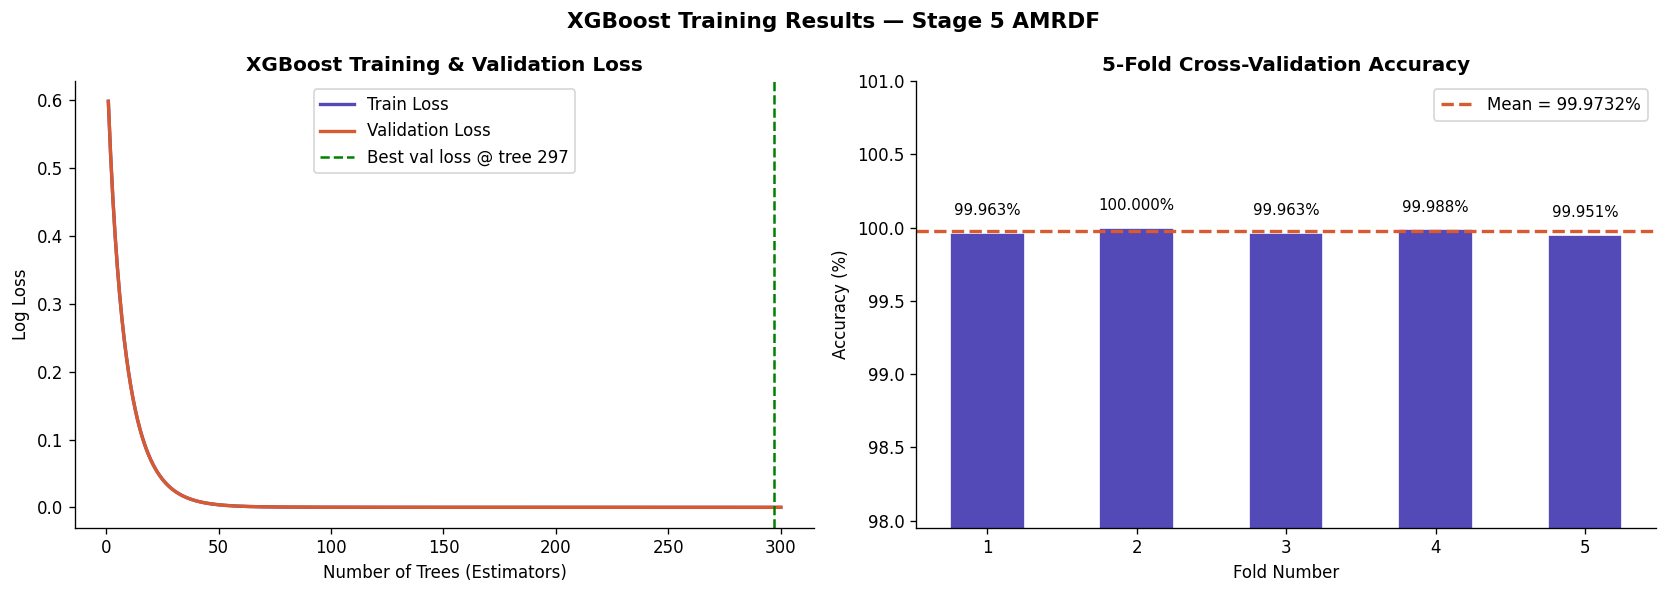


5-Fold CV Results:
  Fold 1: 99.9634%
  Fold 2: 100.0000%
  Fold 3: 99.9634%
  Fold 4: 99.9878%
  Fold 5: 99.9512%
  Mean  : 99.9732%
  Std   : 0.0179%


In [8]:
# ── CELL 6 ──────────────────────────────────────────────────────
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Training loss curve
epochs = range(1, len(train_loss) + 1)
axes[0].plot(epochs, train_loss, color='#534AB7', lw=2, label='Train Loss')
axes[0].plot(epochs, val_loss,   color='#D85A30', lw=2, label='Validation Loss')
axes[0].set_xlabel('Number of Trees (Estimators)')
axes[0].set_ylabel('Log Loss')
axes[0].set_title('XGBoost Training & Validation Loss', fontweight='bold')
axes[0].legend(fontsize=10)
 
best_epoch = np.argmin(val_loss) + 1
axes[0].axvline(best_epoch, color='green', linestyle='--', lw=1.5,
                label=f'Best val loss @ tree {best_epoch}')
axes[0].legend(fontsize=10)
 
# Validation accuracy per fold (5-fold CV)
print("\nRunning 5-fold cross-validation...")
cv_scores = cross_val_score(xgb_model, X_train, y_train,
                            cv=5, scoring='accuracy', n_jobs=-1)
axes[1].bar(range(1, 6), cv_scores * 100,
            color='#534AB7', edgecolor='white', width=0.5)
axes[1].axhline(cv_scores.mean() * 100, color='#D85A30',
                linestyle='--', lw=2,
                label=f'Mean = {cv_scores.mean()*100:.4f}%')
axes[1].set_xlabel('Fold Number')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('5-Fold Cross-Validation Accuracy', fontweight='bold')
axes[1].set_ylim([min(cv_scores)*100 - 2, 101])
axes[1].legend(fontsize=10)
 
for i, score in enumerate(cv_scores, 1):
    axes[1].text(i, score*100 + 0.1, f'{score*100:.3f}%',
                 ha='center', va='bottom', fontsize=9)
 
plt.suptitle('XGBoost Training Results — Stage 5 AMRDF',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'xgboost_training_curves.png'),
            dpi=150, bbox_inches='tight')
plt.show()
 
print(f"\n5-Fold CV Results:")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s*100:.4f}%")
print(f"  Mean  : {cv_scores.mean()*100:.4f}%")
print(f"  Std   : {cv_scores.std()*100:.4f}%")

In [9]:
# ── CELL 7 ──────────────────────────────────────────────────────
# Quick validation check
val_pred     = xgb_model.predict(X_val)
val_acc      = accuracy_score(y_val, val_pred)
val_pred_prob = xgb_model.predict_proba(X_val)[:, 1]
 
print(f"Validation Accuracy : {val_acc*100:.4f}%")
print(f"\nValidation Classification Report:")
print(classification_report(y_val, val_pred,
                            target_names=['Benign','Malicious']))
 

Validation Accuracy : 100.0000%

Validation Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      4396
   Malicious       1.00      1.00      1.00      4395

    accuracy                           1.00      8791
   macro avg       1.00      1.00      1.00      8791
weighted avg       1.00      1.00      1.00      8791



In [10]:
# ── CELL 8 ──────────────────────────────────────────────────────
# Save model and test data for notebook 07
joblib.dump(xgb_model, os.path.join(MODEL_DIR, 'xgboost_model.pkl'))
 
# Save test set for consistent evaluation in notebook 07
test_data = {
    'X_test' : X_test,
    'y_test' : y_test,
    'X_train': X_train,
    'y_train': y_train,
    'X_val'  : X_val,
    'y_val'  : y_val,
    'feature_names': df.drop(columns=['Class']).columns.tolist()
}
joblib.dump(test_data, os.path.join(MODEL_DIR, 'test_data.pkl'))
 
print(f"Saved: xgboost_model.pkl")
print(f"Saved: test_data.pkl")
print(f"\nModel trained on {len(y_train):,} samples")
print(f"Ready for evaluation in Notebook 07")
print("\nNotebook 06 complete — proceed to 07_evaluation_metrics.ipynb")
 

Saved: xgboost_model.pkl
Saved: test_data.pkl

Model trained on 41,015 samples
Ready for evaluation in Notebook 07

Notebook 06 complete — proceed to 07_evaluation_metrics.ipynb
